<img src="../logo_UTN.svg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo Semanal Nº9
#### Federico Borello

### Consigna

Se dispone de [un notebook de referencia](https://nbviewer.org/github/marianux/jupytest/blob/master/Laboratorio%20de%20filtrado%20digital.ipynb) para guionar la práctica de laboratorio. A continuación un breve resumen.

### Parte I - Diseño de filtros
Se necesita eliminar las interferencias de una señal electrocardiográfica (ECG) que fue registrada a una frecuencia de muestreo de $1 [kHz]$. Para ello se propone la siguiente plantilla de diseño:

<div align=center>

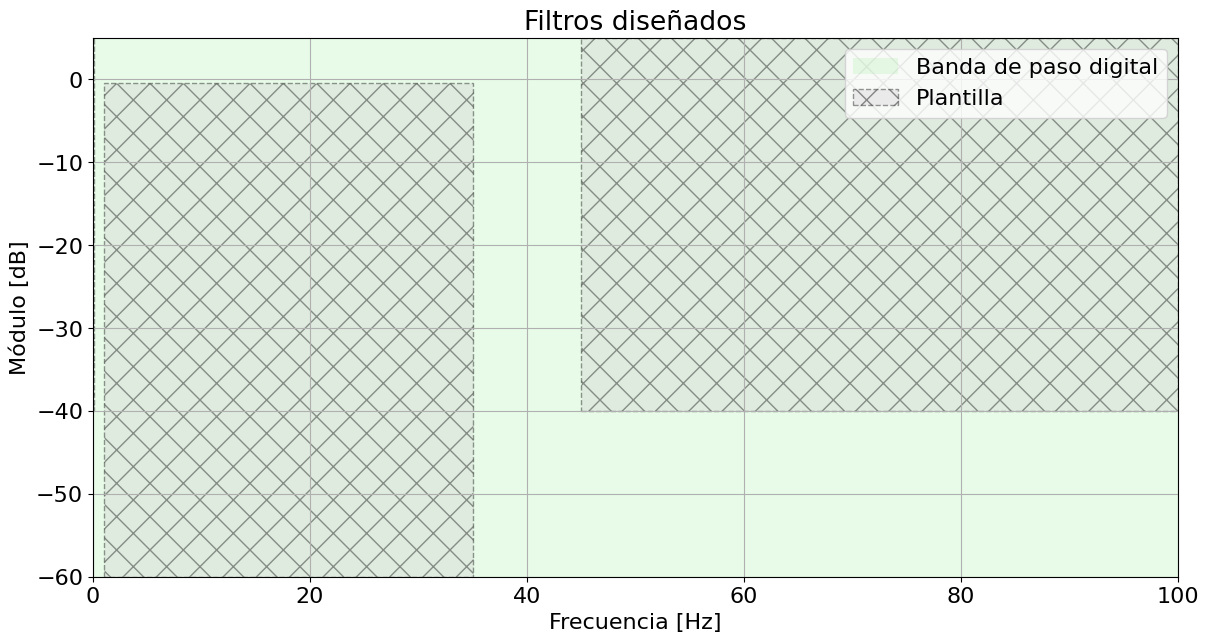

</div>

y se pide diseñar dos filtro IIR y dos filtros FIR que cumplan con la plantilla, utilizando alguno de los métodos estudiados. Mostrar la respuesta en frecuencia, para ambos filtros, de:

1. módulo
2. fase
3. retardo
4. respuesta al impulso.


### Parte II - Implementación y uso

En esta parte utilizaremos los dos filtros diseñados para mitigar las interferencias.


In [ ]:
# Import common packages
from IPython.display import display
import numpy as np
import scipy.signal as sig
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla

import matplotlib.pyplot as plt

In [ ]:
display(sio.whosmat("ecg.mat"))
mat_struct = sio.loadmat("ecg.mat")

ecg_one_lead = mat_struct["ecg_lead"].flatten()

# Parametros del filtro
ripple_db = 0.5  # Ripple en dB
atten_db = 40  # Atenuacion en dB

# Plantilla BandStop
fs1 = 0.1  # Hz
fp1 = 1  # Hz
fp2 = 35  # Hz
fs2 = 45  # Hz

# Parametros del sistema
fs = 1000  # Hz
nyq = fs / 2

In [ ]:
def mag_phase_delay_impulseresp(
    b,
    a,
    sos,
    fs=2,
    worN=512,
    n_imp=1024,
    title=None,
    gd_units="samples",
    max_display_s=0.1,
):
    """
    Plot magnitude, phase, group delay and impulse response.
    - If `sos` is provided (digital SOS) use sosfreqz / sosfilt.
    - gd_units: "samples" or "seconds".
    """

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # --- frequency response
    if sos is not None:
        # w in Hz when fs provided
        w, h = sig.sosfreqz(sos, worN=worN, fs=fs)
    else:
        w, h = sig.freqz(b, a, worN=worN, fs=fs)

    # magnitude
    abs_h = np.abs(h)
    abs_h[abs_h == 0] = 1e-20
    mag_db = 20 * np.log10(abs_h)
    axes[0, 0].plot(w, mag_db, label="Magnitude")
    axes[0, 0].set_ylabel("Magnitude (dB)")
    axes[0, 0].set_xlabel("Frequency (Hz)" if fs else "Frequency (rad)")
    axes[0, 0].grid(True)

    # phase (wrapped) for display
    phase_wrapped = np.angle(h)
    axes[0, 1].plot(w, phase_wrapped, color="orange", label="Phase (wrapped)")
    axes[0, 1].set_ylabel("Phase (rad)")
    axes[0, 1].set_xlabel("Frequency (Hz)" if fs else "Frequency (rad)")
    axes[0, 1].set_ylim(-np.pi, np.pi)
    axes[0, 1].set_yticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
    axes[0, 1].set_yticklabels(
        [r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"]
    )
    axes[0, 1].grid(True)

    # --- group delay (from unwrapped phase)
    # w is in Hz (if fs provided). Convert to angular frequency (rad/s)
    omega = 2 * np.pi * w  # rad/s
    phase_unwrapped = np.unwrap(np.angle(h))
    # numerical derivative d(phase)/d(omega) -> group delay (seconds)
    # use central differences with np.gradient
    gd_seconds = -np.gradient(phase_unwrapped, omega, edge_order=2)
    if gd_units == "samples":
        gd = gd_seconds * fs
        axes[1, 0].set_ylabel("Group Delay (samples)")
    else:
        gd = gd_seconds
        axes[1, 0].set_ylabel("Group Delay (s)")
    axes[1, 0].plot(w, gd, color="green", label="Group Delay")
    axes[1, 0].set_xlabel("Frequency (Hz)" if fs else "Frequency (rad)")
    axes[1, 0].grid(True)

    # --- impulse response via SOS cascade (preserve numerical resolution)
    impulse = np.zeros(n_imp, dtype=float)
    impulse[0] = 1.0
    if sos is not None:
        sos64 = np.asarray(sos, dtype=np.float64)
        imp_resp = sig.sosfilt(sos64, impulse)
    else:
        b64 = np.asarray(b, dtype=np.float64)
        a64 = np.asarray(a, dtype=np.float64)
        imp_resp = sig.lfilter(b64, a64, impulse)

    t = np.arange(n_imp) / fs if fs else np.arange(n_imp)

    # Auto-trim: find last index above relative threshold and set xlim with margin
    abs_resp = np.abs(imp_resp)
    peak = abs_resp.max() if abs_resp.size else 0.0
    tol = 1e-3 * peak  # threshold: 0.1% of peak (adjustable)
    idx = np.where(abs_resp > tol)[0]
    if idx.size:
        last_sig = idx[-1]
        # add small margin of samples (e.g., 10 samples) and convert to seconds
        margin_samples = min(max(1, int(0.01 * fs)), 50) if fs else 1
        t_stop = min(t[-1], t[min(last_sig + margin_samples, n_imp - 1)])
    else:
        # nothing above tol: show a short window (e.g., 10 ms or 10 samples)
        t_stop = min(t[-1], 0.01) if fs else min(n_imp, 10)

    # respect a user cap for maximum displayed seconds (avoid showing 100s)
    if max_display_s is not None:
        t_stop = min(t_stop, max_display_s)

    axes[1, 1].stem(
        t,
        imp_resp,
        linefmt="C3-",
        markerfmt="C3o",
        basefmt="k-",
    )
    axes[1, 1].set_ylabel("Impulse Response")
    axes[1, 1].set_xlabel("Time (s)" if fs else "Samples")
    axes[1, 1].grid(True)
    axes[1, 1].set_xlim(0, max(t_stop, t[1] if t.size > 1 else t[0]))

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    return fig, axes

## Parte I - Diseño de Filtros (Experimentación)

En este apartado se prueban filtros obtener información de cómo abordar el problema.

### Filtros IIR

In [ ]:
# Filtro IIR
approx_funcs = ["butter", "cheby1", "cheby2", "ellip"]

# BandStop
wp = np.array([fp1, fp2])
ws = np.array([fs1, fs2])

# Guardo filtros para luego usar sosfilt y filtrar el ECG
# Se analiza el gráfico de la plantilla de manera visual
sos_iir_butter = []
sos_iir_cheby1 = []

for approx_func in approx_funcs:
    sos_iir = sig.iirdesign(
        wp=wp,
        ws=ws,
        gpass=ripple_db,
        gstop=atten_db,
        analog=False,
        ftype=approx_func,
        fs=fs,
        output="sos",
    )

    if approx_func == "butter":
        sos_iir_butter = sos_iir
    elif approx_func == "cheby1":
        sos_iir_cheby1 = sos_iir

    mag_phase_delay_impulseresp(
        None,
        None,
        sos=sos_iir,
        fs=fs,
        max_display_s=0.3,
        title=f"Filtro IIR - {approx_func}",
    )


plt.show()

In [ ]:
plt.figure(2, figsize=(16, 10))
for approx_func in approx_funcs:
    sos_iir = sig.iirdesign(
        wp=wp,
        ws=ws,
        gpass=ripple_db,
        gstop=atten_db,
        analog=False,
        ftype=approx_func,
        fs=fs,
        output="sos",
    )

    w_rad = np.append(np.logspace(-3, 0.8, 1000), np.logspace(0.9, 1.8, 1000))
    w_rad = np.append(w_rad, np.linspace(64, nyq, 1000, endpoint=True))
    w, h = sig.freqz_sos(sos_iir, worN=w_rad, fs=fs)
    plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=f"{approx_func}")

plot_plantilla(
    filter_type="bandpass",
    fpass=(fp1, fp2),
    fstop=(fs1, fs2),
    ripple=ripple_db,
    attenuation=atten_db,
    fs=fs,
)
plt.axis([0, 100, -60, 5])
plt.title("Comparacion de Filtros IIR")
plt.legend()
plt.show()

### Filtros FIR

In [ ]:
# Filtros FIR
taps_list = [1501, 3001, 5001, 7001, 9001]

plt.figure(figsize=(16, 10))

for taps in taps_list:
    b = sig.firwin2(
        taps,
        freq=(0, fs1, fp1, fp2, fs2, nyq),
        gain=(0, 0, 1, 1, 0, 0),
        window="blackmanharris",
        fs=fs,
    )
    a = 1.0

    # muestreo el filtro donde me interesa verlo según la plantilla.
    w_rad = np.append(np.logspace(-1, 0.8, 250), np.logspace(0.9, 1.6, 250))
    w_rad = np.append(w_rad, np.linspace(110, nyq, 100, endpoint=True))

    w, h_firwin2 = sig.freqz(b, a, worN=w_rad, fs=fs)

    plt.plot(w, 20 * np.log10(np.abs(h_firwin2)), label=f"FIR-Win taps={taps}")

plt.title(f"Respuesta en frecuencia - Filtro BandStop - FIR")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.grid()
plt.axis([0, 100, -60, 5])
plot_plantilla(
    filter_type="bandpass",
    fpass=(fp1, fp2),
    fstop=(fs1, fs2),
    ripple=ripple_db,
    attenuation=atten_db,
    fs=fs,
)
plt.show()

In [ ]:
# Filtros FIR
taps_list = [2001, 3001, 4001, 5001]

# Se eligió de manera arbitraria en base a lo que se observa en el gráfico.
best_taps_firwin2 = 5001
b_firwin2 = []

plt.figure(figsize=(16, 10))

for taps in taps_list:
    b = sig.firwin2(
        taps,
        # Se "pre-distorsiona" la plantilla a mano y de manera heurística se halla la cantidad taps.
        freq=(0, fs1 + 0.5, fp1 - 0.2, fp2 + 0.5, fp2 + 1, nyq),
        gain=(0, 0, 1, 1, 0, 0),
        window=("kaiser", 14),
        fs=fs,
    )
    a = 1.0

    if taps == best_taps_firwin2:
        b_firwin2 = b

    # muestreo el filtro donde me interesa verlo según la plantilla.
    w_rad = np.append(np.logspace(-1.5, 0.8, 250), np.logspace(0.9, 1.6, 250))
    w_rad = np.append(w_rad, np.linspace(110, nyq, 100, endpoint=True))

    w, h_firwin2 = sig.freqz(b, a, worN=w_rad, fs=fs)

    plt.plot(w, 20 * np.log10(np.abs(h_firwin2)), label=f"FIR-Win taps={taps}")

plt.title(f"Respuesta en frecuencia - Filtro BandStop - FIR")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.grid()
plt.axis([0, 2, -60, 5])
plot_plantilla(
    filter_type="bandpass",
    fpass=(fp1, fp2),
    fstop=(fs1, fs2),
    ripple=ripple_db,
    attenuation=atten_db,
    fs=fs,
)
plt.show()

In [ ]:
# Filtros FIR
taps_list = [2001, 3001, 4001, 5001]

# Se eligió de manera arbitraria en base a lo que se observa en el gráfico.
best_taps_firls = 5001
b_firls = []

plt.figure(figsize=(16, 10))

for taps in taps_list:
    b = sig.firls(
        taps,
        # Se "pre-distorsiona" la plantilla a mano y de manera heurística se halla la cantidad taps.
        [0, fs1 + 0.5, fp1 - 0.2, fp2 + 0.5, fp2 + 1, nyq],
        [0, 0, 1, 1, 0, 0],
        fs=fs,
    )

    a = 1.0

    if taps == best_taps_firls:
        b_firls = b

    # muestreo el filtro donde me interesa verlo según la plantilla.
    w_rad = np.append(np.logspace(-1.5, 0.8, 250), np.logspace(0.9, 1.6, 250))
    w_rad = np.append(w_rad, np.linspace(110, nyq, 100, endpoint=True))

    w, h_firwin2 = sig.freqz(b, a, worN=w_rad, fs=fs)

    plt.plot(w, 20 * np.log10(np.abs(h_firwin2)), label=f"FIR-Win taps={taps}")

plt.title(f"Respuesta en frecuencia - Filtro BandStop - FIR")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.grid()
plt.axis([0, 2, -60, 5])
plot_plantilla(
    filter_type="bandpass",
    fpass=(fp1, fp2),
    fstop=(fs1, fs2),
    ripple=ripple_db,
    attenuation=atten_db,
    fs=fs,
)
plt.show()

## Parte II - Filtrado del ECG

In [ ]:
# Plot de las señales ECG One Lead

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ecg_one_lead_broad = ecg_one_lead[:150000]

axes[0].plot(ecg_one_lead_broad)
axes[0].set_title("ECG One Lead")
axes[0].grid()

ecg_one_lead_zoom = ecg_one_lead[:15000]

axes[1].plot(ecg_one_lead_zoom)
axes[1].set_title("ECG One Lead - Zoom")
axes[1].grid()

plt.show()

In [ ]:
# Filtrado de las señales ECG One Lead con sig.sosfilt()
# Hay distorsión de fase que debe solucionarse.
# Con sig.sosfiltfilt() se soluciona internamente.
ecg_one_lead_zoom_filtered_by_iir_butter = sig.sosfilt(
    sos_iir_butter, ecg_one_lead_zoom
)
ecg_one_lead_broad_filtered_by_iir_butter = sig.sosfilt(
    sos_iir_butter, ecg_one_lead_broad
)

ecg_one_lead_zoom_filtered_by_iir_cheby1 = sig.sosfilt(
    sos_iir_cheby1, ecg_one_lead_zoom
)
ecg_one_lead_broad_filtered_by_iir_cheby1 = sig.sosfilt(
    sos_iir_cheby1, ecg_one_lead_broad
)


fig, axes = plt.subplots(4, 1, figsize=(16, 15))

# Plot Filtrado IIR Butter de ECG One Lead - Zoom
axes[0].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[0].plot(ecg_one_lead_zoom_filtered_by_iir_butter, label="Filtrado IIR Butter")
axes[0].set_title("ECG One Lead - Zoom - Filtrado IIR Butter")
axes[0].grid()

# Plot Filtrado IIR Butter de ECG One Lead - Broad
axes[1].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[1].plot(ecg_one_lead_broad_filtered_by_iir_butter, label="Filtrado IIR Butter")
axes[1].set_title("ECG One Lead - Broad - Filtrado IIR Butter")
axes[1].grid()

# Plot Filtrado IIR Cheby1 de ECG One Lead - Zoom
axes[2].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[2].plot(ecg_one_lead_zoom_filtered_by_iir_cheby1, label="Filtrado IIR Cheby1")
axes[2].set_title("ECG One Lead - Zoom - Filtrado IIR Cheby1")
axes[2].grid()

# Plot Filtrado IIR Cheby1 de ECG One Lead - Broad
axes[3].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[3].plot(ecg_one_lead_broad_filtered_by_iir_cheby1, label="Filtrado IIR Cheby1")
axes[3].set_title("ECG One Lead - Broad - Filtrado IIR Cheby1")
axes[3].grid()

In [ ]:
ecg_one_lead_zoom_filtered_by_iir_butter = sig.sosfiltfilt(
    sos_iir_butter, ecg_one_lead_zoom
)
ecg_one_lead_broad_filtered_by_iir_butter = sig.sosfiltfilt(
    sos_iir_butter, ecg_one_lead_broad
)

ecg_one_lead_zoom_filtered_by_iir_cheby1 = sig.sosfiltfilt(
    sos_iir_cheby1, ecg_one_lead_zoom
)
ecg_one_lead_broad_filtered_by_iir_cheby1 = sig.sosfiltfilt(
    sos_iir_cheby1, ecg_one_lead_broad
)

fig, axes = plt.subplots(4, 1, figsize=(16, 15))

# Plot Filtrado IIR Butter de ECG One Lead - Zoom
axes[0].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[0].plot(ecg_one_lead_zoom_filtered_by_iir_butter, label="Filtrado IIR Butter")
axes[0].set_title("ECG One Lead - Zoom - Filtrado IIR Butter")
axes[0].grid()

# Plot Filtrado IIR Butter de ECG One Lead - Broad
axes[1].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[1].plot(ecg_one_lead_broad_filtered_by_iir_butter, label="Filtrado IIR Butter")
axes[1].set_title("ECG One Lead - Broad - Filtrado IIR Butter")
axes[1].grid()

# Plot Filtrado IIR Cheby1 de ECG One Lead - Zoom
axes[2].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[2].plot(ecg_one_lead_zoom_filtered_by_iir_cheby1, label="Filtrado IIR Cheby1")
axes[2].set_title("ECG One Lead - Zoom - Filtrado IIR Cheby1")
axes[2].grid()

# Plot Filtrado IIR Cheby1 de ECG One Lead - Broad
axes[3].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[3].plot(ecg_one_lead_broad_filtered_by_iir_cheby1, label="Filtrado IIR Cheby1")
axes[3].set_title("ECG One Lead - Broad - Filtrado IIR Cheby1")
axes[3].grid()

In [ ]:
ecg_one_lead_zoom_filtered_by_firwin2 = sig.lfilter(b_firwin2, [1], ecg_one_lead_zoom)
ecg_one_lead_broad_filtered_by_firwin2 = sig.lfilter(b_firwin2, [1], ecg_one_lead_broad)

ecg_one_lead_zoom_filtered_by_firls = sig.lfilter(b_firls, [1], ecg_one_lead_zoom)
ecg_one_lead_broad_filtered_by_firls = sig.lfilter(b_firls, [1], ecg_one_lead_broad)


fig, axes = plt.subplots(4, 1, figsize=(16, 15))

# Arreglar la demora del filtro FIR
# Es lo mismo que obtener la shape() del filtro y restarle 1, luego dividir por 2.
delay_firwin = (best_taps_firwin2 - 1) // 2
delay_firls = (best_taps_firls - 1) // 2

# Plot Filtrado FIR Win de ECG One Lead - Zoom
axes[0].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[0].plot(
    ecg_one_lead_zoom_filtered_by_firwin2[delay_firwin:-delay_firwin],
    label="Filtrado FIR Win Sin Demora",
)
# axes[0].plot(ecg_one_lead_zoom_filtered_by_firwin2, label="Filtrado FIR Win")
axes[0].set_title("ECG One Lead - Zoom - Filtrado FIR Win")
axes[0].grid()
axes[0].legend()

# Plot Filtrado FIR Win de ECG One Lead - Broad
axes[1].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[1].plot(
    ecg_one_lead_broad_filtered_by_firwin2, label="Filtrado FIR Win Sin Demora"
)
# axes[1].plot(
#     ecg_one_lead_broad_filtered_by_firwin2[delay_firwin:-delay_firwin], label="Filtrado FIR Win"
# )
axes[1].set_title("ECG One Lead - Broad - Filtrado FIR Win")
axes[1].grid()
axes[1].legend()

# Plot Filtrado FIR Ls de ECG One Lead - Zoom
axes[2].plot(ecg_one_lead_zoom, label="ECG Zoom Original")
axes[2].plot(
    ecg_one_lead_zoom_filtered_by_firls[delay_firls:-delay_firls],
    label="Filtrado FIR Ls sin Demora",
)
# axes[2].plot(ecg_one_lead_zoom_filtered_by_firls, label="Filtrado FIR Ls")
axes[2].set_title("ECG One Lead - Zoom - Filtrado FIR Ls")
axes[2].grid()
axes[2].legend()

# Plot Filtrado FIR Ls de ECG One Lead - Broad
axes[3].plot(ecg_one_lead_broad, label="ECG Broad Original")
axes[3].plot(
    ecg_one_lead_broad_filtered_by_firls[delay_firls:-delay_firls],
    label="Filtrado FIR Ls Sin Demora",
)
# axes[3].plot(ecg_one_lead_broad_filtered_by_firls, label="Filtrado FIR Ls")
axes[3].set_title("ECG One Lead - Broad - Filtrado FIR Ls")
axes[3].grid()
axes[3].legend()

plt.show()

In [ ]:
# Comparación de los filtros
regs_interes = (
    [4000, 5500],  # muestras
    [10e3, 11e3],  # muestras
)

for ii in regs_interes:

    # intervalo limitado de 0 a len(ecg_one_lead_broad)
    zoom_region = np.arange(
        np.max([0, ii[0]]), np.min([len(ecg_one_lead_broad), ii[1]]), dtype="uint"
    )

    plt.figure(figsize=(16, 10), facecolor="w", edgecolor="k")
    plt.plot(zoom_region, ecg_one_lead_broad[zoom_region], label="ECG", linewidth=2)
    plt.plot(
        zoom_region,
        ecg_one_lead_broad_filtered_by_firls[zoom_region + delay_firls],
        label="firls",
    )
    plt.plot(
        zoom_region,
        ecg_one_lead_broad_filtered_by_firwin2[zoom_region + delay_firwin],
        label="firwin2",
    )
    plt.plot(
        zoom_region, ecg_one_lead_broad_filtered_by_iir_cheby1[zoom_region], label="iir"
    )

    plt.title("ECG filtering example from " + str(ii[0]) + " to " + str(ii[1]))
    plt.ylabel("Adimensional")
    plt.xlabel("Muestras (#)")

    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())

    plt.show()

## Comparación de los filtros y Conclusiones

Se aprecia que el filtro `IIR` muestra oscilaciones, además se requiere mucha carga computacional para diseñar un filtro de orden elevado.

El filtro `FIR` diseñado con `firwin2` y `firls` muestran un comportamiento similar, se debe realizar una "pre-distorsión" de plantilla para que el algoritmo interno de las funciones cumplan con las especificaciones deseadas.

Las funciones para aplicar los filtros `lfilter` (para FIR) y `sosfilt`/`sosfiltfilt` (para IIR) son muy sencillas de utilizar pero la función `sosfiltfilt` es mucho mejor en comparación con `sosfilt`, ya que aplica el filtro en ambos sentidos, evitando así problemas de fase y retardos.

Las oscilaciones luego del pico R del ECG se deben a que el filtro lo interpreta como un impulso, siendo las oscilaciones algo similar a la respuesta al impulso del filtro.

Como conclusión, se recomienda el uso de filtros `FIR` para este tipo de aplicaciones, ya que no presentan inestabilidades y son más sencillos de diseñar. Las funciones proporcionadas por `scipy.signal` facilitan el diseño de los mismos y permiten obtener filtros personalizados y dependiendo de las necesidades del usuario se pueden tener más o menos taps. A mayor cantidad de taps, mejor será la aproximación a la plantilla deseada, pero se requiere mayor carga computacional, es un trade-off a tener en cuenta que resulta muy sencillo de manejar con las funciones para diseño de filtros `FIR`.